# Analyse de Données et Modèle de Classification

## Chargement - Analyse - Nettoyage

### Chargement

In [1]:
import pandas as pd
import numpy as np

In [2]:
players = pd.read_csv("nba_logreg.csv")

In [3]:
players.head()

,Name,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0.0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0.0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0.0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1.0
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1.0


### Valeurs Manquantes

In [4]:
# Analyse des valeurs manquantes
missing_values = players.isnull().sum()

print("valeurs manquantes")
print(missing_values)

valeurs manquantes
Name            0
GP              0
MIN             0
PTS             0
FGM             0
FGA             0
FG%             0
3P Made         0
3PA             0
3P%            11
FTM             0
FTA             0
FT%             0
OREB            0
DREB            0
REB             0
AST             0
STL             0
BLK             0
TOV             0
TARGET_5Yrs     0
dtype: int64


In [5]:
print("lignes avec NA")
print(players[players.isna().any(axis=1)])
# je remarque que les valeurs NA sont justifiées car on ne peut pas définir de 3P% s'il n'y a pas de 3P attempt
# on va donc considérer sur ces lignes que 3P% est 0

lignes avec NA
               Name  GP   MIN   PTS  FGM  FGA   FG%  3P Made  3PA  3P%  ...  \
338     Ken Johnson  64  12.7   4.1  1.8  3.3  52.8      0.0  0.0  NaN  ...   
339     Ken Johnson  64  12.7   4.1  1.8  3.3  52.8      0.0  0.0  NaN  ...   
340   Pete Williams  53  10.8   2.8  1.3  2.1  60.4      0.0  0.0  NaN  ...   
358   Melvin Turpin  79  24.7  10.6  4.6  9.0  51.1      0.0  0.0  NaN  ...   
386    Jim Petersen  60  11.9   3.2  1.2  2.4  48.6      0.0  0.0  NaN  ...   
397   Tom Scheffler  39   6.9   1.3  0.5  1.3  41.2      0.0  0.0  NaN  ...   
507    Sam Williams  59  18.2   6.1  2.6  4.7  55.6      0.0  0.0  NaN  ...   
509   Kurt Nimphius  63  17.2   5.3  2.2  4.7  46.1      0.0  0.0  NaN  ...   
510  Pete Verhoeven  71  17.0   4.9  2.1  4.2  50.3      0.0  0.0  NaN  ...   
521       Jim Smith  72  11.9   2.9  1.2  2.3  50.9      0.0  0.0  NaN  ...   
559    Jeff Wilkins  56  18.9   4.7  2.1  4.6  45.0      0.0  0.0  NaN  ...   

     FTA   FT%  OREB  DREB  REB  AST

In [6]:
players1 = players.copy()
players1["3P%"] = players1["3P%"].fillna(0)

### Duplicatas

J'ai remarqué en parcourant les données qu'il y avait des duplicatas troublants où les valeurs sont strictement identiques (donc probablement les mêmes joueurs) et où le target est 0 puis 1.

In [7]:
duplicatas = players1.drop(columns=["TARGET_5Yrs"]).duplicated(keep=False)  # On cherche à isoler les lignes où toutes les valeurs du X sont identiques
players_duplicatas = players1[duplicatas]  # Filtrer uniquement les lignes dupliquées
players_duplicatas.head(10)

,Name,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
18,Larry Johnson,82,37.2,19.2,7.5,15.3,49.0,0.1,0.3,22.7,...,5.0,82.9,3.9,7.0,11.0,3.6,1.0,0.6,1.9,0.0
19,Larry Johnson,82,37.2,19.2,7.5,15.3,49.0,0.1,0.3,22.7,...,5.0,82.9,3.9,7.0,11.0,3.6,1.0,0.6,1.9,1.0
71,Dee Brown,82,23.7,8.7,3.5,7.5,46.4,0.1,0.4,20.6,...,1.9,87.3,0.5,1.7,2.2,4.2,1.0,0.2,1.7,0.0
72,Dee Brown,82,23.7,8.7,3.5,7.5,46.4,0.1,0.4,20.6,...,1.9,87.3,0.5,1.7,2.2,4.2,1.0,0.2,1.7,1.0
73,Dee Brown,49,9.2,1.9,0.7,2.0,32.7,0.1,0.6,21.4,...,0.8,64.9,0.2,0.7,0.8,1.7,0.5,0.1,0.6,0.0
74,Dee Brown,49,9.2,1.9,0.7,2.0,32.7,0.1,0.6,21.4,...,0.8,64.9,0.2,0.7,0.8,1.7,0.5,0.1,0.6,1.0
120,Tim Hardaway,79,33.7,14.7,5.9,12.5,47.1,0.3,1.1,27.4,...,3.5,76.4,0.7,3.2,3.9,8.7,2.1,0.1,3.3,0.0
121,Tim Hardaway,79,33.7,14.7,5.9,12.5,47.1,0.3,1.1,27.4,...,3.5,76.4,0.7,3.2,3.9,8.7,2.1,0.1,3.3,1.0
126,Glen Rice,77,30.0,13.6,6.1,13.9,43.9,0.2,0.9,24.6,...,1.6,73.4,1.3,3.3,4.6,1.8,0.9,0.3,1.5,1.0
127,Glen Rice,77,30.0,13.6,6.1,13.9,43.9,0.2,0.9,24.6,...,1.6,73.4,1.3,3.3,4.6,1.8,0.9,0.3,1.5,0.0


En analysant les duplicatas, il est difficile de prendre une décision sur comment gérer ceci. Le problème n'est pas que des joueurs ont le même nom, des mêmes statistiques. C'est que ces lignes semblent dupliquées et ont pour la plupart des Y_target différents et parfois les mêmes, sans avoir la certitude que ce sont bien des joueurs différents.

Il aurait fallu connaitre plus sur la méthode d'acquisition du dataset pour corriger les erreurs ou supprimer les doublons.

Dans le cas où on aurait eu des joueurs bien différents, on garderait chacune des lignes (sacrée coincidence que toutes les variables soient identique cependant).
Dans le cas où certaines lignes sont en doublons, alors on suprimerait les lignes supplémentaires et les lignes erronnées (pour un même joueur, le target ne peut pas être 0 et 1).

Comme je ne connais pas la méthode de constitution du dataset. Je vais tenter une approche en nettoyant le plus rigoureusement possible la base (avec des recherches rapides pour les quelques joueurs dupliqués), et je ferai un deuxieme apprentissage avec la base complète comme si chaque ligne était un joueur différent, mais les performances devraient en être détériorées.

In [8]:
# Lignes doublons complets (X et Y)
doublons = players1.duplicated()
print(f"Nombre de doublons : {doublons.sum()}")

duplicatas1 = players1.duplicated(keep=False)  # On cherche à isoler les lignes où toutes les valeurs du X sont identiques
players_duplicatas1 = players1[duplicatas1]  # Filtrer uniquement les lignes dupliquées
print(players_duplicatas1.head())

# Supprimer les doublons complets
players2 = players1.drop_duplicates()
print(players2.duplicated().sum())

# Afficher les doublons en X avec Y contradictoire
duplicatas2 = players2.drop(columns=["TARGET_5Yrs"]).duplicated(keep=False)  # On cherche à isoler les lignes où toutes les valeurs du X sont identiques
players_duplicatas2 = players2[duplicatas2]  # Filtrer uniquement les lignes dupliquées
players_duplicatas2[["Name","GP","TARGET_5Yrs"]]

Nombre de doublons : 12
              Name  GP   MIN   PTS  FGM   FGA   FG%  3P Made  3PA   3P%  ...  \
162  Charles Smith  60   8.7   2.9  1.0   2.2  44.4      0.0  0.1   0.0  ...   
163  Charles Smith  60   8.7   2.9  1.0   2.2  44.4      0.0  0.1   0.0  ...   
165  Charles Smith  71  30.4  16.3  6.1  12.4  49.5      0.0  0.0   0.0  ...   
166  Charles Smith  71  30.4  16.3  6.1  12.4  49.5      0.0  0.0   0.0  ...   
168  Charles Smith  34   8.6   3.5  1.4   3.7  39.2      0.4  1.4  31.9  ...   

     FTA   FT%  OREB  DREB  REB  AST  STL  BLK  TOV  TARGET_5Yrs  
162  1.3  69.7   0.2   0.9  1.2  1.7  0.6  0.1  0.6          1.0  
163  1.3  69.7   0.2   0.9  1.2  1.7  0.6  0.1  0.6          1.0  
165  5.5  72.5   2.4   4.1  6.5  1.5  1.0  1.3  2.1          1.0  
166  5.5  72.5   2.4   4.1  6.5  1.5  1.0  1.3  2.1          1.0  
168  0.3  54.5   0.4   0.4  0.8  0.6  0.3  0.2  0.8          1.0  

[5 rows x 21 columns]
0


,Name,GP,TARGET_5Yrs
18,Larry Johnson,82,0.0
19,Larry Johnson,82,1.0
71,Dee Brown,82,0.0
72,Dee Brown,82,1.0
73,Dee Brown,49,0.0
74,Dee Brown,49,1.0
120,Tim Hardaway,79,0.0
121,Tim Hardaway,79,1.0
126,Glen Rice,77,1.0
127,Glen Rice,77,0.0


In [9]:
# une petite recherche sur basketball-reference.com, la fiabilité des données n'est pas sûre à 100% car je ne suis pas un expert dans le domaine et j'ai pu confondre des joueurs
indices_faux = [18, 71, 74, 120, 127, 156, 159, 164, 167, 168, 224, 225, 365, 367, 472, 554, 849, 871, 1127, 1229]

# Suppression des lignes
players2 = players2.drop(indices_faux)

players2

,Name,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0.0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0.0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0.0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1.0
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,Chris Smith,80,15.8,4.3,1.6,3.6,43.3,0.0,0.2,14.3,...,1.5,79.2,0.4,0.8,1.2,2.5,0.6,0.2,0.8,0.0
1336,Brent Price,68,12.6,3.9,1.5,4.1,35.8,0.1,0.7,16.7,...,1.0,79.4,0.4,1.1,1.5,2.3,0.8,0.0,1.3,1.0
1337,Marlon Maxey,43,12.1,5.4,2.2,3.9,55.0,0.0,0.0,0.0,...,1.6,64.3,1.5,2.3,3.8,0.3,0.3,0.4,0.9,0.0
1338,Litterial Green,52,12.0,4.5,1.7,3.8,43.9,0.0,0.2,10.0,...,1.8,62.5,0.2,0.4,0.7,2.2,0.4,0.1,0.8,1.0


On a 2 datasets players1 et players2, le premier sans modifications sur les duplicatas et le deuxieme avec une tentative de nettoyage (mais pas sûre car je ne sais pas comment on a constitué le dataset au départ

### Visualisation des variables, vérification, valeurs aberrantes?

Matrice de corrélation :
               GP       MIN       PTS       FGM       FGA       FG%   3P Made  \
GP       1.000000  0.590497  0.538867  0.543280  0.518928  0.288999  0.114253   
MIN      0.590497  1.000000  0.910975  0.901778  0.909576  0.200394  0.394750   
PTS      0.538867  0.910975  1.000000  0.990741  0.979965  0.252283  0.351191   
FGM      0.543280  0.901778  0.990741  1.000000  0.979926  0.289659  0.292868   
FGA      0.518928  0.909576  0.979965  0.979926  1.000000  0.127191  0.394085   
FG%      0.288999  0.200394  0.252283  0.289659  0.127191  1.000000 -0.291380   
3P Made  0.114253  0.394750  0.351191  0.292868  0.394085 -0.291380  1.000000   
3PA      0.106481  0.409128  0.361747  0.303208  0.417649 -0.347512  0.982701   
3P%      0.044732  0.172016  0.159437  0.126290  0.204024 -0.329406  0.589178   
FTM      0.479895  0.789901  0.895462  0.846974  0.826867  0.240322  0.161321   
FTA      0.477149  0.778851  0.880669  0.840542  0.806879  0.294431  0.097951   
FT%

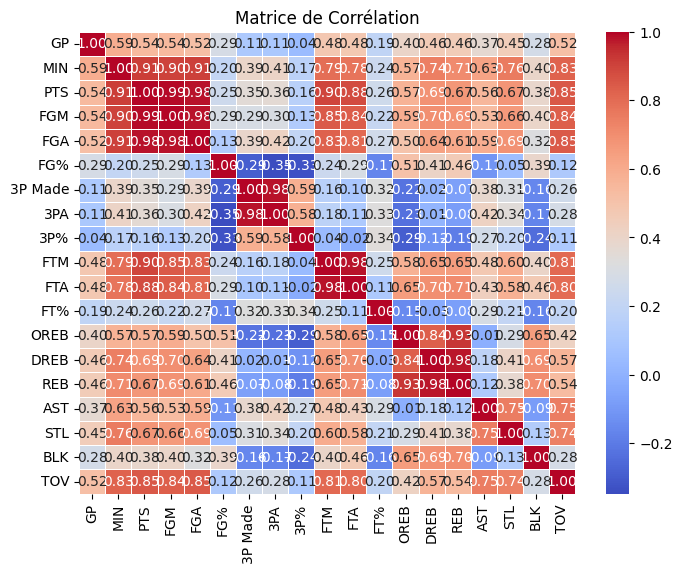

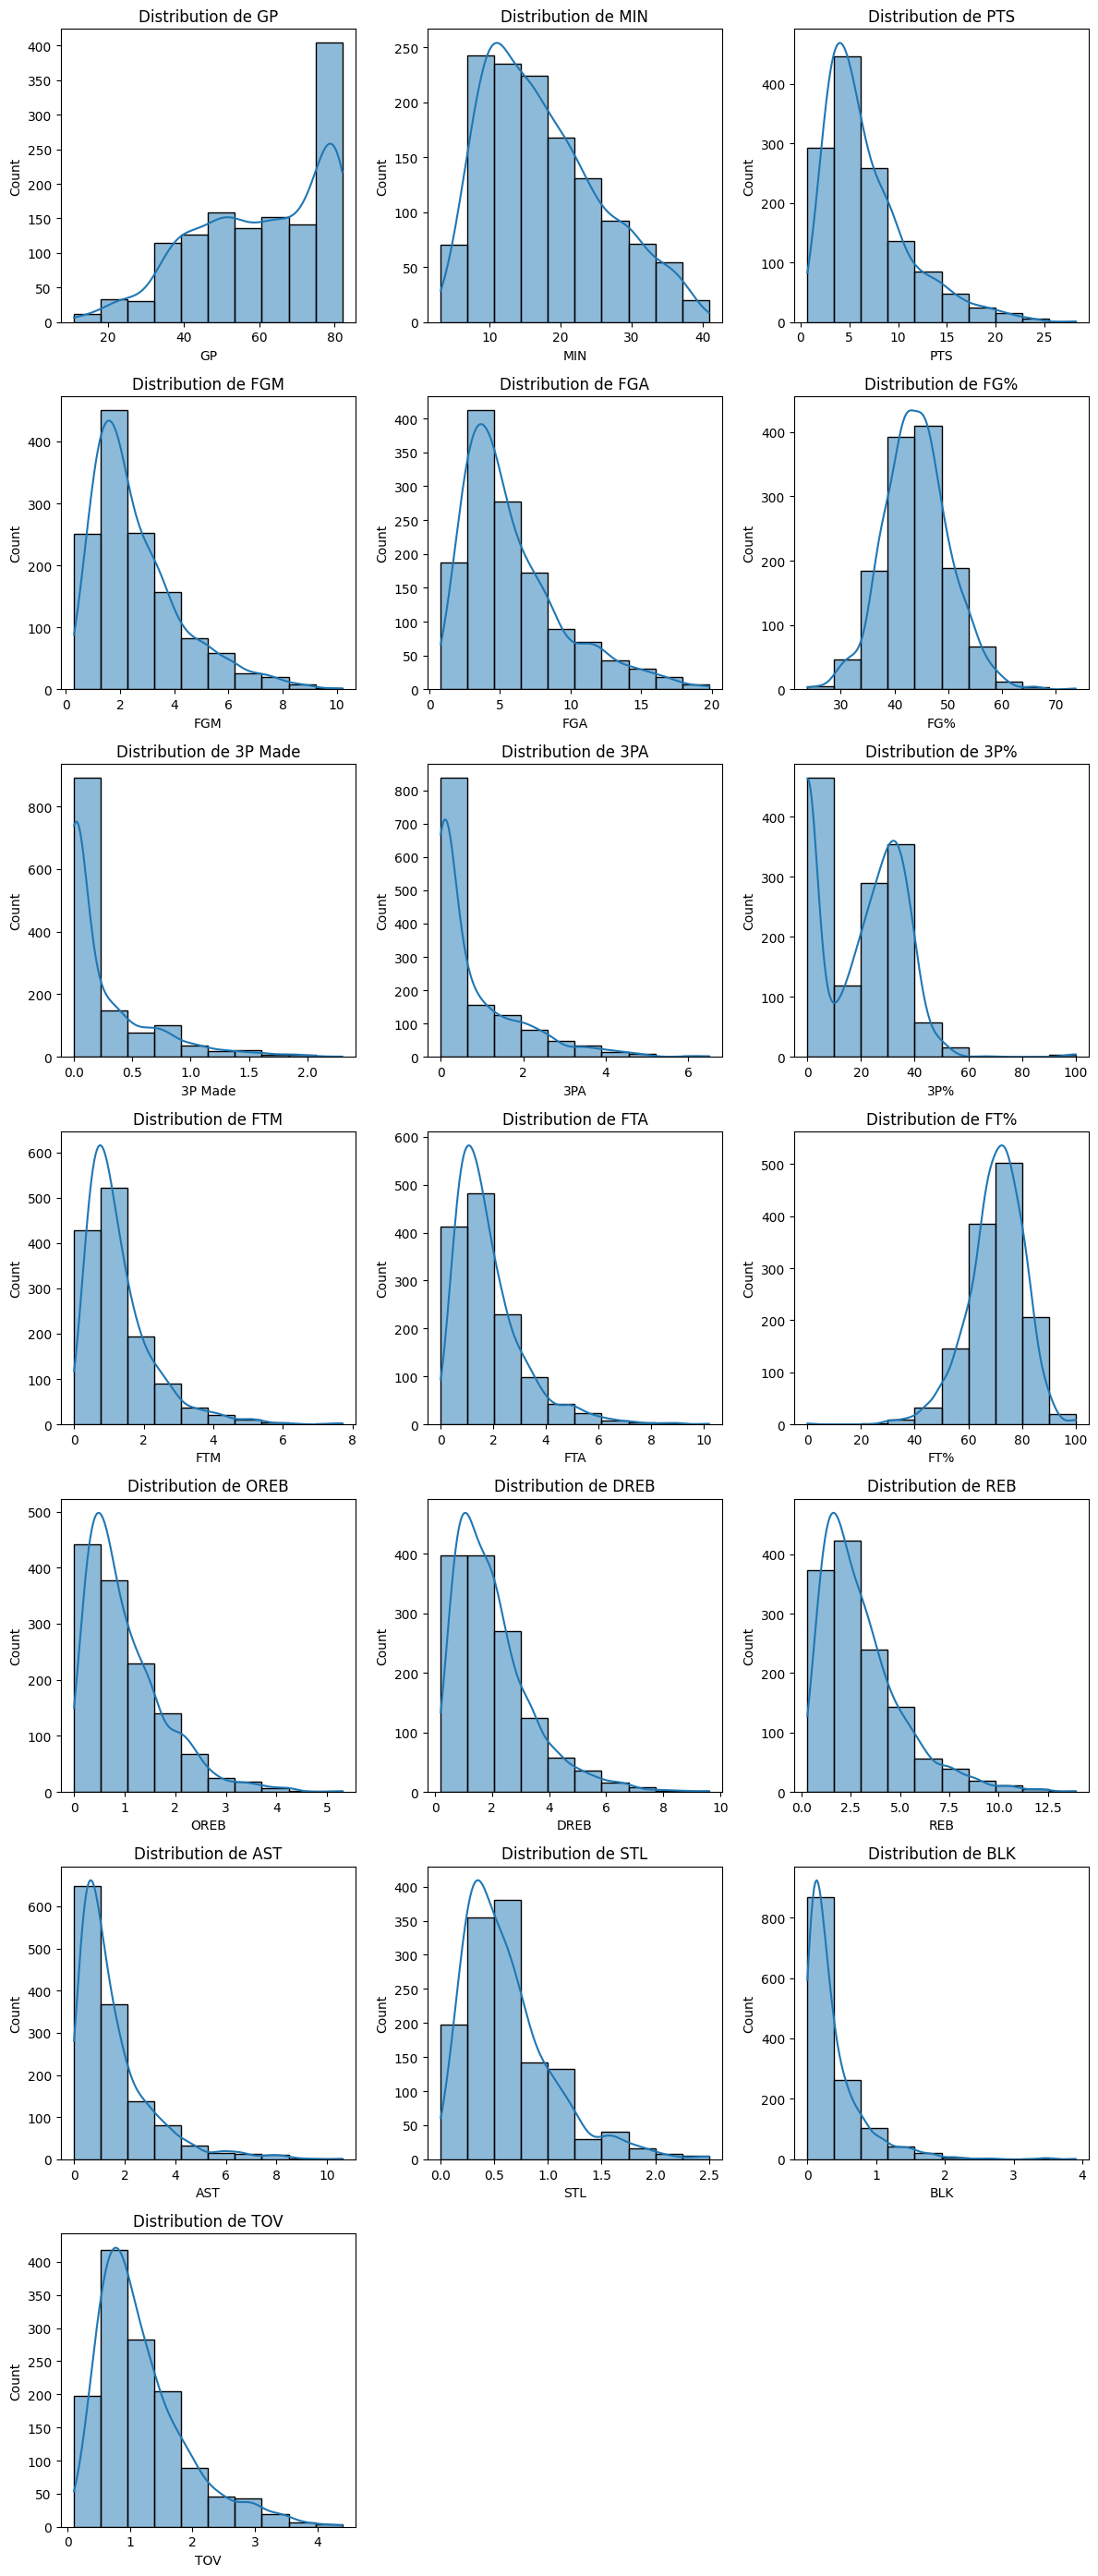

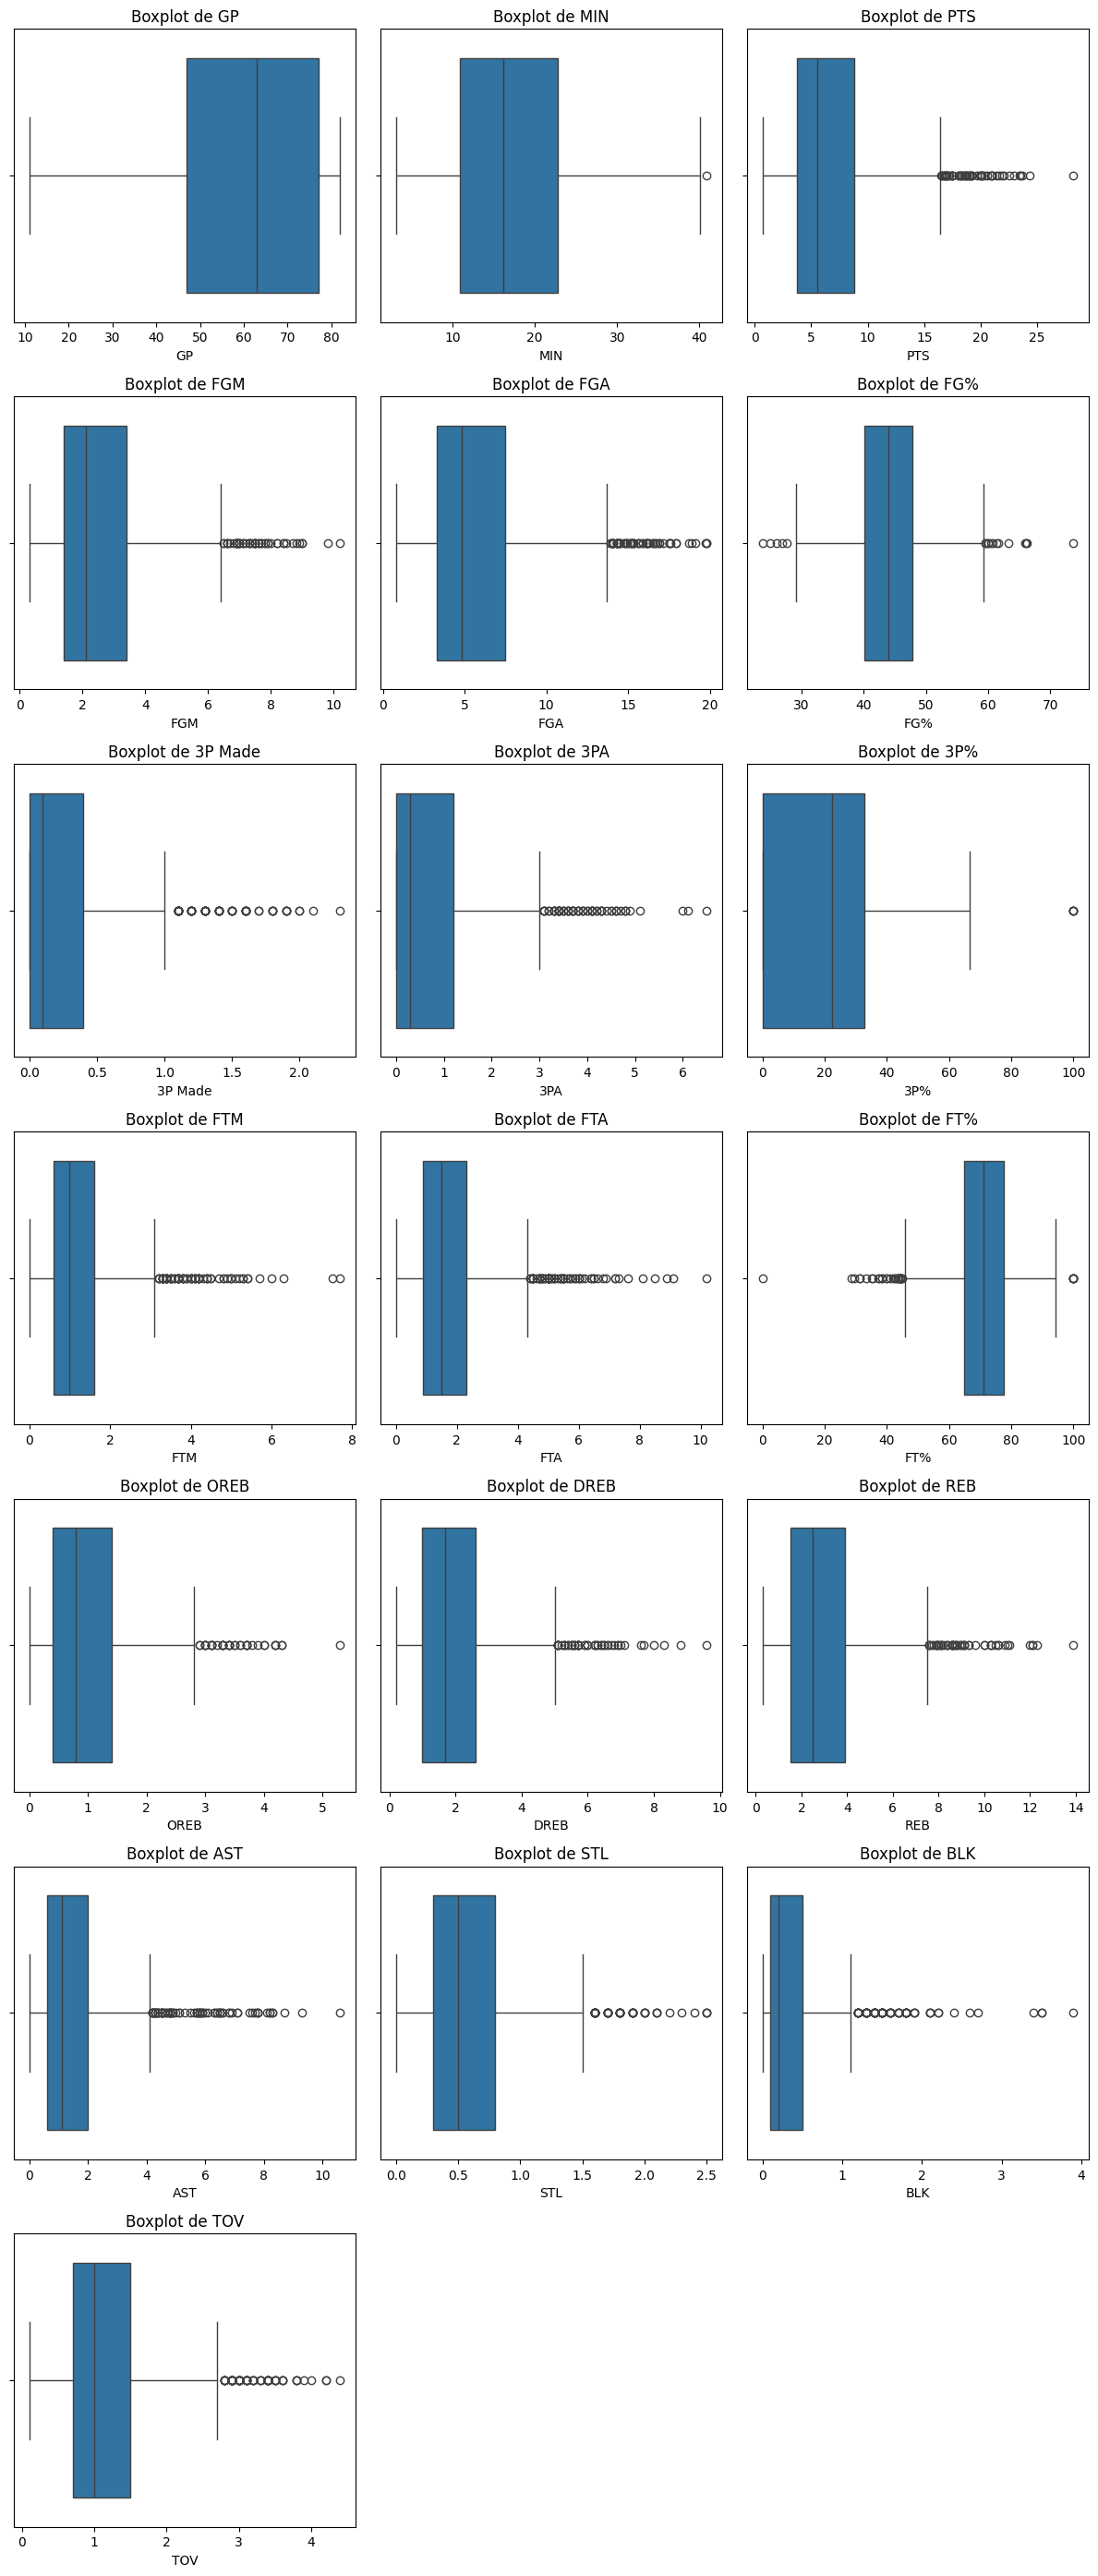

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

df = players2.drop(columns=["Name","TARGET_5Yrs"])

# 1. Analyse des corrélations entre les colonnes numériques
correlation_matrix = df.corr()
print("Matrice de corrélation :")
print(correlation_matrix)

# Visualisation de la matrice de corrélation avec un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.show()


# 2. Analyse des distributions avec des histogrammes et KDE
# Calcul du nombre de sous-graphes nécessaires
n_columns = len(df.columns)  # Nombre de colonnes
n_rows = math.ceil(n_columns / 3)  # Nombre de lignes, 3 colonnes par ligne

plt.figure(figsize=(12, 4 * n_rows))
for i, column in enumerate(df.columns, 1):
    plt.subplot(n_rows, 3, i)  # 3 colonnes par ligne
    sns.histplot(df[column], kde=True, bins=10)  # Histogramme avec KDE
    plt.title(f'Distribution de {column}')

plt.tight_layout()
plt.show()

# 3. Détection des valeurs aberrantes avec un diagramme boite à moustaches
plt.figure(figsize=(12, 4 * n_rows))
for i, column in enumerate(df.columns, 1):
    plt.subplot(n_rows, 3, i)  # 3 colonnes par ligne
    sns.boxplot(x=df[column])  # Boxplot pour chaque colonne
    plt.title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

A la visualisation des histogrammes et boxplots, je n'ai pas trouvé de valeur "aberrante" a priori par rapport au contexte de l'étude.

La matrice des corrélations indique que certaines variables sont fortement correllées. C'est peu surprenant, en effet, par exemple, un joueur ayant joué plus de matchs a plus de chances d'avoir marqué plus de points, ou le nombre de 3P Made est très dépendant du nombre de 3P Attempts.




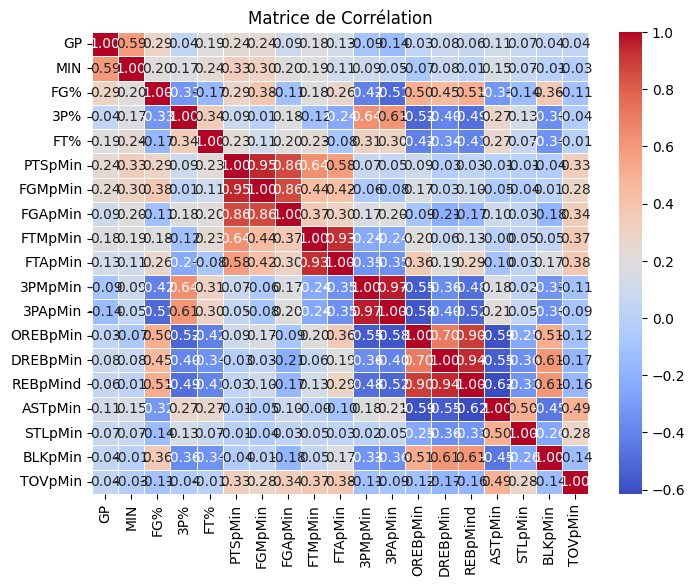

In [11]:
players3 = players2.copy()
players3["PTSpMin"] = players3["PTS"] / players3["MIN"].replace(0,np.nan)
players3["FGMpMin"] = players3["FGM"] / players3["MIN"].replace(0,np.nan)
players3["FGApMin"] = players3["FGA"] / players3["MIN"].replace(0,np.nan)
players3["FTMpMin"] = players3["FTM"] / players3["MIN"].replace(0,np.nan)
players3["FTApMin"] = players3["FTA"] / players3["MIN"].replace(0,np.nan)
players3["3PMpMin"] = players3["3P Made"] / players3["MIN"].replace(0,np.nan)
players3["3PApMin"] = players3["3PA"] / players3["MIN"].replace(0,np.nan)
players3["OREBpMin"] = players3["OREB"] / players3["MIN"].replace(0,np.nan)
players3["DREBpMin"] = players3["DREB"] / players3["MIN"].replace(0,np.nan)
players3["REBpMind"] = players3["REB"] / players3["MIN"].replace(0,np.nan)
players3["ASTpMin"] = players3["AST"] / players3["MIN"].replace(0,np.nan)
players3["STLpMin"] = players3["STL"] / players3["MIN"].replace(0,np.nan)
players3["BLKpMin"] = players3["BLK"] / players3["MIN"].replace(0,np.nan)
players3["TOVpMin"] = players3["TOV"] / players3["MIN"].replace(0,np.nan)

players3 = players3.drop(columns=["PTS","FGM","FGA","FTM","FTA","3P Made","3PA","OREB","DREB","REB","AST","STL","BLK","TOV"])

df1 = players3.drop(columns=["Name","TARGET_5Yrs"])
# 1. Analyse des corrélations entre les colonnes numériques
correlation_matrix1 = df1.corr()


# Visualisation de la matrice de corrélation avec un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix1, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.show()


On a un nouveau dataset avec des features "par minute", les variables sont moins correlées entre elles. Il reste toujours la correllation entre les attempts et les made, mais pour régler cela, j'envisage de sélectionner une des deux variables simplement et délaisser les autres.

### Distribution des valeurs de Y

In [12]:
target_distribution1 = players1["TARGET_5Yrs"].value_counts(normalize=True) * 100
print(target_distribution1)

target_distribution2 = players2["TARGET_5Yrs"].value_counts(normalize=True) * 100
print(target_distribution2)

TARGET_5Yrs
1.0    62.014925
0.0    37.985075
Name: proportion, dtype: float64
TARGET_5Yrs
1.0    62.614679
0.0    37.385321
Name: proportion, dtype: float64


## Tests de modèles, Apprentissage

### Jeux train et test

In [13]:
#print(players1.head(1))
#print(players2.head(1))
#print(players3.head(1))

In [14]:
from sklearn.model_selection import train_test_split

X1 = players1.drop(columns=["Name","TARGET_5Yrs"]) 
y1 = players1["TARGET_5Yrs"]  

# Split 80% train, 20% test
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

X1_train.shape,X1_test.shape


((1072, 19), (268, 19))

In [15]:
X2 = players2.drop(columns=["Name","TARGET_5Yrs"]) 
y2 = players2["TARGET_5Yrs"]  

# Split 80% train, 20% test
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

X2_train.shape,X2_test.shape

((1046, 19), (262, 19))

In [16]:
X3 = players3.drop(columns=["Name","TARGET_5Yrs"]) 
y3 = players3["TARGET_5Yrs"]  

# Split 80% train, 20% test
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

X3_train.shape,X3_test.shape

((1046, 19), (262, 19))

### Tests Régression Logistique

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

X, y = X3, y3
print(X3.head(1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Validation croisée avec une régression logistique
logreg = LogisticRegression(solver='liblinear')  
cross_val_accuracy = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"Scores de validation croisée (accuracy) : {cross_val_accuracy}")
print(f"Moyenne des scores de validation croisée : {cross_val_accuracy.mean():.4f}")

# Ajuster le modèle sur l'ensemble d'entraînement
logreg.fit(X_train_scaled, y_train)

# Extraire les coefficients avec les noms des variables
coefficients = pd.DataFrame({'Variable': X_train.columns, 'Coefficient': logreg.coef_[0]})
print("\n Coefficients du modèle (triés) :\n", coefficients)

# accuracy du modèle sur le test
y_pred = logreg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Accuracy sur test : {accuracy:.4f}")

#  statsmodels pour obtenir les p-values et significativités
X_const = pd.DataFrame(sm.add_constant(X_scaled), columns=['Intercept'] + list(X_train.columns))
X_const = X_const.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
logreg_stats = sm.Logit(y_train, X_const).fit()
print("\n Significativité des coefficients avec statsmodels :\n")
print(logreg_stats.summary())

# AUC
roc_auc = roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:, 1])
print(f"\n AUC (aire sous la courbe ROC) : {roc_auc:.4f}")



   GP   MIN   FG%   3P%   FT%   PTSpMin   FGMpMin   FGApMin   FTMpMin  \
0  36  27.4  34.7  25.0  69.9  0.270073  0.094891  0.277372  0.058394   

    FTApMin   3PMpMin   3PApMin  OREBpMin  DREBpMin  REBpMind   ASTpMin  \
0  0.083942  0.018248  0.076642  0.025547  0.124088  0.149635  0.069343   

    STLpMin   BLKpMin   TOVpMin  
0  0.014599  0.014599  0.047445  
Scores de validation croisée (accuracy) : [0.74285714 0.75598086 0.70813397 0.71291866 0.71291866]
Moyenne des scores de validation croisée : 0.7266

 Coefficients du modèle (triés) :
     Variable  Coefficient
0         GP     0.661294
1        MIN     0.340569
2        FG%     0.068193
3        3P%     0.173505
4        FT%     0.036016
5    PTSpMin     0.765518
6    FGMpMin    -0.336512
7    FGApMin    -0.183889
8    FTMpMin     0.328621
9    FTApMin    -0.456030
10   3PMpMin     0.460331
11   3PApMin    -0.672412
12  OREBpMin     0.083579
13  DREBpMin    -0.216189
14  REBpMind     0.518928
15   ASTpMin     0.301177
16   ST

In [47]:
# # chemin des coefficients (régularisation L1)
# lambdas = np.logspace(-4, 4, 100)  # Plage de valeurs de régularisation entre 10^-4 et 10^4
# coefs = []

# # Pour chaque valeur de lambda, ajuster un modèle et sauvegarder les coefficients
# for lam in lambdas:
#     model = LogisticRegression(penalty='l1', C=1/lam, solver='liblinear')
#     model.fit(X_train_scaled, y_train)
#     coefs.append(model.coef_)

# # Convertir en tableau numpy
# coefs = np.array(coefs)

# # Tracer les coefficients
# plt.figure(figsize=(10, 6))
# print(coefs.shape)

# for i in range(coefs.shape[2]):
#     plt.plot(lambdas, coefs[:,0,i], label=f'{X_train.columns[i]}')
    
# plt.xscale('log')
# plt.xlabel('Lambda (régularisation)')
# plt.ylabel('Coefficients')
# plt.title('Chemin des coefficients pour la régression logistique avec régularisation L1')
# plt.legend()
# plt.show()

Conclusion des essais avec Régression Logistique :
Les résultats pour une régression logistique ne sont pas satisfaisants. L'Accuracy sur le test et pour la validation croisée sont autour de 72%. C'est faible surtout quand on sait que, en raison du déséquilibre des classes, le modèle constant aurait une Accuracy de 62% environ.

De plus, avec la régression logistique de statsmodel (pour afficher les p-valeurs et le R²), on observe que pas un coefficient sur nos variables n'est significatif.


